<a href="https://colab.research.google.com/github/eteitelbaum/code-satp/blob/main/models/classification-models/targettype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn scikit-multilearn

## Create A Fixed Split Where 20% is Reserved for Testing

In [ ]:
def create_fixed_splits(df_full, stratify_cols, test_size=0.2, val_size=0.1, random_state=42):
    """
    Splits a multi-label classification dataset into fixed training, validation, and test sets
    using iterative stratification to preserve label distributions across splits.

    This function is designed for experiments where:
      - The test set must remain fixed across all model runs.
      - The validation set is also fixed and used for model selection.
      - Only the training set is progressively sampled in size.

    Parameters:
        df_full (pd.DataFrame): Full labeled dataset, including the input text column and multi-label targets.
        stratify_cols (list of str): Column names representing the multi-label targets used for stratification.
        test_size (float): Fraction of the full dataset to reserve as the test set (default: 0.2).
        val_size (float): Fraction of the remaining training pool to use as the validation set (default: 0.1).
        random_state (int): Seed for reproducibility.

    Returns:
        df_train_pool (pd.DataFrame): Training pool to draw progressively larger subsets from.
        df_val (pd.DataFrame): Fixed validation set (real-only, for model tuning).
        df_test (pd.DataFrame): Fixed test set (real-only, for final evaluation).

    Notes:
        - All DataFrames returned preserve the original index from df_full.
        - Iterative stratification ensures that rare labels are proportionally distributed across splits.
    """

    # Extract text and multi-label target arrays
    X = df_full["incident_summary"].values
    y = df_full[stratify_cols].values

    # Step 1: Split full data into train+val vs. test using iterative stratification
    stratifier = IterativeStratification(
        n_splits=2,
        order=1,
        sample_distribution_per_fold=[1 - test_size, test_size]
    )
    for trainval_idx, test_idx in stratifier.split(X, y):
        break

    # Use .iloc to preserve original DataFrame indices
    df_trainval = df_full.iloc[trainval_idx]
    df_test = df_full.iloc[test_idx]

    # Step 2: Split trainval into training pool vs. validation set
    X_trainval = df_trainval["incident_summary"].values
    y_trainval = df_trainval[stratify_cols].values

    stratifier2 = IterativeStratification(
        n_splits=2,
        order=1,
        sample_distribution_per_fold=[1 - val_size, val_size]
    )
    for train_idx, val_idx in stratifier2.split(X_trainval, y_trainval):
        break

    df_train_pool = df_trainval.iloc[train_idx]
    df_val = df_trainval.iloc[val_idx]

    return df_train_pool, df_val, df_test

## Previous Method--Create New Spit with Each Iteration

In [10]:
# import numpy as np
# import pandas as pd
# from skmultilearn.model_selection import IterativeStratification

# def iterative_train_test_split_custom(X, y, test_size, random_state=None):
#     """
#     Splits X and y using iterative stratification and returns data + indices.
#     """
#     stratifier = IterativeStratification(
#         n_splits=2,
#         order=1,
#         sample_distribution_per_fold=[1 - test_size, test_size]
#     )

#     indices = np.arange(len(X))
#     for train_idx, test_idx in stratifier.split(X, y):
#         return (
#             X[test_idx], y[test_idx], test_idx,
#             X[train_idx], y[train_idx], train_idx
#         )


# def stratified_split(df, x_col, stratify_cols, test_size, val_size=None, random_state=None, return_indices=False):
#     """
#     Splits a DataFrame into stratified sets using iterative stratification.

#     Parameters:
#       df           : pandas DataFrame.
#       x_col        : column name containing the features (e.g., "incident_summary").
#       stratify_cols: list of column names to use for stratification.
#       train_size   : fraction for training (used for information; priority is given to training and validation).
#       test_size    : fraction for test set.
#       val_size     : (optional) fraction for validation set. If None, a two-split (train/test) is performed.
#       random_state : seed for reproducibility.

#     Returns:
#       If val_size is None:
#          (X_train, y_train, X_test, y_test)
#       Else:
#          (X_train, y_train, X_val, y_val, X_test, y_test)

#     Note: When using a validation set, it is assumed that train_size + test_size + val_size == 1.
#     """
#     # Shuffle the DataFrame if a random state is provided.
#     if random_state is not None:
#         df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

#     # Extract features and stratification labels.
#     X = df[x_col].values
#     y = df[stratify_cols].values

#     if val_size is None:
#         X_test, y_test, test_idx, X_train, y_train, train_idx = iterative_train_test_split_custom(X, y, test_size, random_state)

#         if return_indices:
#             return X_train, y_train, X_test, y_test, train_idx, test_idx
#         else:
#             return X_train, y_train, X_test, y_test

#     else:
#         temp_size = test_size + val_size
#         X_temp, y_temp, temp_idx, X_train, y_train, train_idx = iterative_train_test_split_custom(X, y, temp_size, random_state)

#         ratio = test_size / temp_size
#         X_test, y_test, test_idx, X_val, y_val, val_idx = iterative_train_test_split_custom(X_temp, y_temp, ratio, random_state)

#         if return_indices:
#             return X_train, y_train, X_val, y_val, X_test, y_test, train_idx, val_idx, test_idx
#         else:
#             return X_train, y_train, X_val, y_val, X_test, y_test


## Imports

In [ ]:
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

## Dataset Class

In [1]:
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float),
        }

## Metrics Function

In [7]:
def compute_metrics(eval_pred, target_names):
    """
    Compute evaluation metrics for multi-label classification.
    Includes Hamming Loss, Subset Accuracy, and Classification Report for all labels.
    """
    logits, labels = eval_pred
    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy()  # Apply threshold
    labels = labels.astype(int)

    # Verify Labels
    print("Shape of labels:", labels.shape)  # Ensures correct dimensions
    print("First few rows of labels:\n", labels[:5])  # Shows the first few rows to check for issues
    print("Final target names:", target_names)

    # Hamming Loss
    hamming = hamming_loss(labels, predictions)

    # Subset Accuracy
    subset_acc = accuracy_score(labels, predictions)

    # Classification Report
    report = classification_report(
        labels, predictions,
        target_names=target_names,
        zero_division=0, output_dict=True
    )

    # Print complete report for reference
    print("\nFull Classification Report:")
    print(classification_report(labels, predictions, target_names=target_names, zero_division=0))


    # Summary Metrics for Trainer
    metrics = {
        "hamming_loss": hamming,
        "subset_accuracy": subset_acc,
    }
    metrics.update(report)
    return metrics

## Model Training Function (Fixed Splits)

In [ ]:
# =======================
# Transformer Training with Fixed Splits
# =======================
def train_transformer_model(model_name, df_train, df_val, df_test, max_len=512, batch_size=16, epochs=2):
    """
    Trains a transformer model for multi-label classification using fixed train/val/test splits.

    This version assumes the data has already been stratified and split externally,
    and that original DataFrame indices have been preserved for traceability.

    Parameters:
        model_name (str): Name or path of the pre-trained HuggingFace model to fine-tune.
        df_train (pd.DataFrame): Training set with 'incident_summary' and label columns.
        df_val (pd.DataFrame): Validation set for model selection and early stopping.
        df_test (pd.DataFrame): Test set used for final evaluation.
        max_len (int): Maximum input token length for the tokenizer (default: 512).
        batch_size (int): Batch size for both training and evaluation (default: 16).
        epochs (int): Number of fine-tuning epochs (default: 2).

    Returns:
        trainer (transformers.Trainer): The HuggingFace Trainer object after training.
        test_results (dict): Evaluation metrics on the test set.
        pred_df (pd.DataFrame): DataFrame with true labels, predictions, probabilities,
                                incident summary text, and original indices.
    """
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=df_train.shape[1] - 1,  # All columns except 'incident_summary'
        problem_type="multi_label_classification",
    )
    model.to("cuda" if torch.cuda.is_available() else "cpu")

    # Identify label columns
    target_names = [col for col in df_train.columns if col != "incident_summary"]

    # Prepare datasets
    train_dataset = MultiLabelDataset(df_train["incident_summary"].tolist(), df_train[target_names].values, tokenizer, max_len)
    val_dataset = MultiLabelDataset(df_val["incident_summary"].tolist(), df_val[target_names].values, tokenizer, max_len)
    test_dataset = MultiLabelDataset(df_test["incident_summary"].tolist(), df_test[target_names].values, tokenizer, max_len)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model='eval_hamming_loss',
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
    )

    # Set up Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)
    )

    # Train the model
    trainer.train()

    # Final evaluation on test set
    test_results = trainer.evaluate(test_dataset)

    # Predictions
    predictions_output = trainer.predict(test_dataset)
    logits = predictions_output.predictions
    labels = predictions_output.label_ids
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    binary_preds = (probs > 0.5).astype(int)

    # Build predictions DataFrame
    pred_df = pd.DataFrame()
    for i, col in enumerate(target_names):
        pred_df[f"true_{col}"] = labels[:, i]
        pred_df[f"pred_{col}"] = binary_preds[:, i]
        pred_df[f"prob_{col}"] = probs[:, i]

    pred_df["incident_summary"] = df_test["incident_summary"].values
    pred_df["original_idx"] = df_test.index

    return trainer, test_results, pred_df

## Older Training Function

In [4]:

# # =======================
# # Reusable Training Function
# # =======================
# def train_transformer_model(model_name, data, max_len=512, test_size=0.1, val_size=0.1, batch_size=40, epochs=3):
#     """
#     Generalized function to train a transformer model for multi-label classification.
#     Args:
#         model_name: Name of the pre-trained model (e.g., "bert-base-uncased", "distilbert-base-uncased").
#         data: Pandas DataFrame with columns "incident_summary" and multi-label columns.
#         max_len: Maximum sequence length.
#         batch_size: Batch size for training and evaluation.
#         epochs: Number of training epochs.
#     """
#     # Load tokenizer and model
#     tokenizer = AutoTokenizer.from_pretrained(model_name)
#     model = AutoModelForSequenceClassification.from_pretrained(
#         model_name,
#         num_labels=data.shape[1] - 1,  # Number of labels (all columns except "incident_summary")
#         problem_type="multi_label_classification",
#     )
#     model.to("cuda" if torch.cuda.is_available() else "cpu")

#     target_names = data.drop(columns=["incident_summary"]).columns.tolist()

#     # Split data into train, val, and test
#     X = data["incident_summary"]
#     y = data.drop('incident_summary', axis=1).values

#     # Keep original indices
#     original_indices = X.index

#     # X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42) #stratify=y)
#     # X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)




#     # X_train, y_train, X_test, y_test = stratified_split(
#     #     data,
#     #     x_col="incident_summary",
#     #     stratify_cols=[col for col in data.columns if col != "incident_summary"],
#     #     train_size=0.9,
#     #     test_size=0.1,
#     #     val_size=None,
#     #     random_state=42
#     # )

#     X_train, y_train, X_val, y_val, X_test, y_test, _, _, test_idx = stratified_split(
#         data,
#         x_col="incident_summary",
#         stratify_cols=[col for col in data.columns if col != "incident_summary"],
#         test_size=test_size,
#         val_size=val_size,
#         random_state=42,
#         return_indices=True
#     )


#     # Create datasets
#     train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer, max_len)
#     val_dataset = MultiLabelDataset(X_val.tolist(), y_val, tokenizer, max_len)
#     test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer, max_len)

#     # Define training arguments
#     training_args = TrainingArguments(
#         output_dir="./results",
#         eval_strategy="epoch",
#         save_strategy="epoch",
#         learning_rate=2e-5,
#         per_device_train_batch_size=batch_size,
#         per_device_eval_batch_size=batch_size,
#         num_train_epochs=epochs,
#         weight_decay=0.01,
#         logging_dir="./logs",
#         logging_steps=10,
#         load_best_model_at_end=True,
#         metric_for_best_model='eval_hamming_loss',
#         greater_is_better=True,
#         save_total_limit=2,
#         report_to="none",
#     )

#     # Initialize Trainer
#     trainer = Trainer(
#         model=model,
#         args=training_args,
#         train_dataset=train_dataset,
#         eval_dataset=val_dataset,
#         processing_class=tokenizer,
#         compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)
#     )

#     # Train and Evaluate
#     trainer.train()

#     # Final Evaluation on Test Set
#     test_results = trainer.evaluate(test_dataset)
#     print("Test Set Results:", test_results)

#     # ---------------------------
#     # Generate Predictions on Test Set
#     # ---------------------------
#     predictions_output = trainer.predict(test_dataset)
#     logits = predictions_output.predictions
#     labels = predictions_output.label_ids

#     # Convert logits to probabilities
#     probs = torch.sigmoid(torch.tensor(logits)).numpy()

#     # Apply threshold to get binary predictions
#     binary_preds = (probs > 0.5).astype(int)

#     # Build predictions DataFrame
#     predictions_df = pd.DataFrame()
#     for i, col in enumerate(target_names):
#         predictions_df[f"true_{col}"] = labels[:, i]
#         predictions_df[f"pred_{col}"] = binary_preds[:, i]
#         predictions_df[f"prob_{col}"] = probs[:, i]

#     # Add original row index from the full dataset for traceability
#     predictions_df["original_idx"] = data.index[test_idx]

#     # Add original text summary for manual inspection of predictions
#     predictions_df["incident_summary"] = data.iloc[test_idx]["incident_summary"].values

#     return trainer, test_results, predictions_df


## Experiment Configuration

In [8]:
# Mapping of fraction values to human-readable labels for plotting/logging
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

# Mapping of HuggingFace model names to short labels for reports/plots
model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

# Training set fractions to experiment with (progressive sizes)
fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

# HuggingFace model identifiers to fine-tune and compare
model_names = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]


## Run Experiments Function

In [ ]:
def run_all_experiments_and_save(
    df_full,
    stratify_cols,
    output_csv="results_summary.csv",
    predictions_csv="all_predictions.csv",
    test_size=0.2,
    val_size=0.1,
    max_len=512,
    batch_size=16,
    epochs=2
):
    """
    Runs multi-label classification experiments with varying training sizes and model architectures.

    Workflow:
        1. Uses a fixed stratified train/val/test split of the full dataset.
        2. For each training fraction:
            a. Subsamples that fraction from the training pool.
            b. Trains and evaluates each model using the same val/test sets.
            c. Records results and predictions.
        3. Saves summary results and all predictions to CSV.

    Parameters:
        df_full (pd.DataFrame): Full dataset, including text and label columns.
        stratify_cols (list of str): List of label column names to use for stratified splitting.
        output_csv (str): File path to save experiment summary results.
        predictions_csv (str): File path to save all raw model predictions.
        test_size (float): Fraction of the data to reserve for testing (default: 0.2).
        val_size (float): Fraction of the train pool to use for validation (default: 0.1).
        max_len (int): Max token length for transformer inputs.
        batch_size (int): Batch size for training and evaluation.
        epochs (int): Number of training epochs per model run.

    Returns:
        results_df (pd.DataFrame): Aggregated evaluation metrics for each model/fraction.
        full_pred_df (pd.DataFrame): All predictions with metadata for downstream analysis.
    """
    # Step 1: Fixed train/val/test split
    df_train_pool, df_val, df_test = create_fixed_splits(
        df_full,
        stratify_cols=stratify_cols,
        test_size=test_size,
        val_size=val_size,
        random_state=42
    )

    results_list = []
    all_predictions = []

    for frac in fractions:
        # Subsample a fraction of the training pool
        subset_size = int(len(df_train_pool) * frac)
        df_train_subset = df_train_pool.sample(n=subset_size, random_state=42)

        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac_label} ({subset_size} rows) ===")

        for model_name in model_names:
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")

            # Train and evaluate
            trainer, test_results, pred_df = train_transformer_model(
                model_name,
                df_train=df_train_subset,
                df_val=df_val,
                df_test=df_test,
                max_len=max_len,
                batch_size=batch_size,
                epochs=epochs
            )

            # Record summary metrics
            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }

            for key, value in test_results.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        run_result[f"{key}_{subkey}"] = subvalue
                else:
                    run_result[key] = value

            results_list.append(run_result)

            # Tag predictions with metadata
            pred_df["model"] = model_name
            pred_df["model_label"] = model_label
            pred_df["fraction"] = frac
            pred_df["fraction_label"] = frac_label
            all_predictions.append(pred_df)

    # Save summary results
    results_df = pd.DataFrame(results_list)
    results_df.to_csv(output_csv, index=False)
    print(f"\nResults saved to {output_csv}")

    # Save all predictions
    full_pred_df = pd.concat(all_predictions, ignore_index=True)
    full_pred_df.to_csv(predictions_csv, index=False)
    print(f"All predictions saved to {predictions_csv}")

    return results_df, full_pred_df

## Older Experiments Function

In [6]:
# def run_all_experiments_and_save(df_full, output_csv="results_summary.csv", predictions_csv="all_predictions.csv"):
#     """
#     1. Iterates over the defined fractions & model list
#     2. Samples df_full according to fraction
#     3. Trains & evaluates using train_multiclass_model_3way_split
#     4. Saves the collected results in a DataFrame
#     5. Exports to CSV

#     Args:
#         df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
#         output_csv (str): File path to save the experiment results.
#     Returns:
#         results_df (pd.DataFrame): Contains experiment results for analysis.
#     """
#     results_list = []

#     all_predictions = []

#     for frac in fractions:
#         # Sample a fraction of the data
#         subset_size = int(len(df_full) * frac)
#         df_subset = df_full.sample(n=subset_size, random_state=42)

#         # Friendly fraction label if you want
#         frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
#         print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

#         for model_name in models_list:
#             # Model label
#             model_label = model_name_labels.get(model_name, model_name)
#             print(f"Training model: {model_label}")

#             # Train & evaluate
#             # write the model funtion here
#             trainer, test_results, test_predictions = train_transformer_model(model_name, df_subset, max_len=512, test_size=0.1, val_size=0.1, batch_size=16, epochs=2)


#             # Build a result dict
#             run_result = {
#                 "fraction_raw": frac,
#                 "fraction_label": frac_label,
#                 "subset_size": subset_size,
#                 "model_raw": model_name,
#                 "model_label": model_label
#             }

#             # Flatten the nested dictionary
#             for key, value in test_results.items():
#                 if isinstance(value, dict):
#                     for subkey, subvalue in value.items():
#                         # Create new key names like "armed_assault_precision"
#                         run_result[f"{key}_{subkey}"] = subvalue
#                 else:
#                     run_result[key] = value

#             # Append to results_list
#             results_list.append(run_result)

#             # Add metadata columns
#             test_predictions["model"] = model_name
#             test_predictions["model_label"] = model_label
#             test_predictions["fraction"] = frac
#             test_predictions["fraction_label"] = frac_label

#             # Store in full list
#             all_predictions.append(test_predictions)

#     # Convert to DataFrame
#     results_df = pd.DataFrame(results_list)
#     # Save to CSV
#     results_df.to_csv(output_csv, index=False)
#     print(f"\nResults saved to {output_csv}")

#     # Concatenate and save all predictions
#     full_pred_df = pd.concat(all_predictions, ignore_index=True)
#     full_pred_df.to_csv(predictions_csv, index=False)
#     print("All predictions saved to all_predictions.csv")

#     # also save to JSON
#     # results_df.to_json("experiment_results.json", orient="records")

#     return results_df, full_pred_df


# **Read From Drive**

In [15]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/colab/satp-data/target_type.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Read from GitHub**

In [ ]:
import pandas as pd

# URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/refs/heads/main/data/target_type.csv'

try:
    data = pd.read_csv(url)
    print(data.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

In [ ]:


selected_columns = ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target', 'incident_summary']
data = data[selected_columns]

# Now 'data' contains only the selected columns.
print(data.head())


## Run the Models

In [ ]:
# Example usage:
final_results_df, predictions_df = run_all_experiments_and_save(
    data,
    output_csv="targettype_summary.csv",
    predictions_csv = "targettype_predictions.csv")

# Inspect final_results_df in Python:
print(final_results_df.head())

## Commit Results to GitHub

In [ ]:
# commit csv to github using python

from github import Github
import pandas as pd
import os

# Replace with your GitHub personal access token
g = Github("your_github_access_token")

# Replace with your repository name and owner
repo = g.get_user("your_github_username").get_repo("your_repository_name")

# Specify the path to the CSV file in your Colab environment
csv_file_path = "experiment_results.csv"

# Check if the file exists
if not os.path.exists(csv_file_path):
    print(f"Error: CSV file '{csv_file_path}' not found.")
else:
    # Create a file object and commit
    try:
        with open(csv_file_path, 'rb') as file_obj:
            contents = repo.create_file(
                path="experiment_results.csv",  # Specify the path in your repository
                message="Committing CSV file from Colab",
                content=file_obj.read(),
                branch="main"  # Replace with your branch name
            )
        print("CSV file successfully committed to GitHub!")
    except Exception as e:
        print(f"Error committing CSV file to GitHub: {e}")


## Save to Disc

In [ ]:
import os


def save_to_drive(df, filename, folder_name="targettype"):
    base_path = "/content/drive/MyDrive/colab/satp-results/"
    drive_path = os.path.join(base_path, folder_name)

    # Create the folder if it doesn't exist
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)

    filepath = os.path.join(drive_path, filename)
    df.to_csv(filepath, index=False)
    print(f"✅ DataFrame saved to: {filepath}")

save_to_drive(final_results_df, "targettype_summary.csv")
save_to_drive(predictions_df, "targettype_predictions.csv")



## Analyze Results

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/targettype/targettype_results.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### F1 Micro

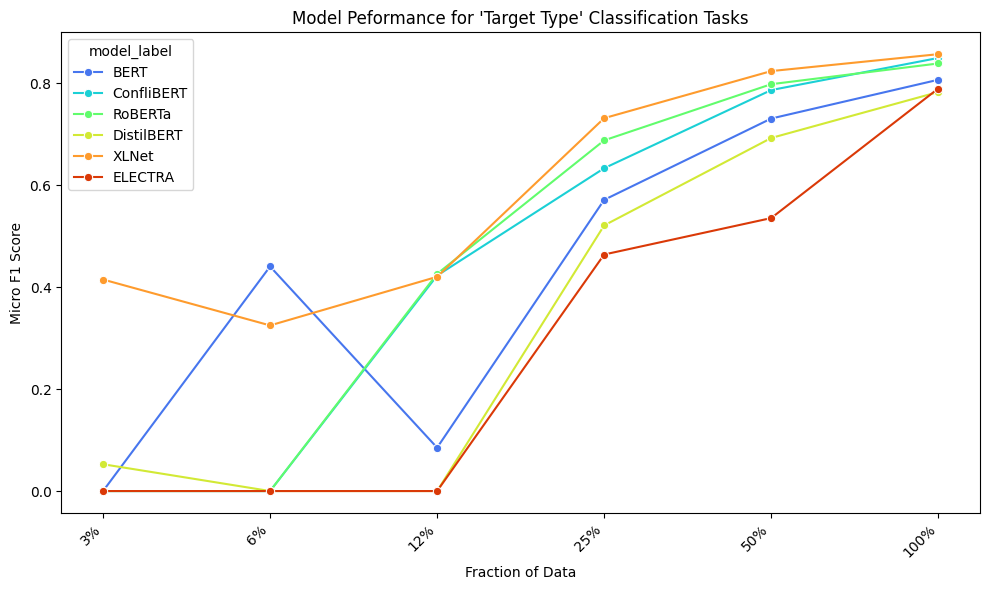

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="fraction_label",
    y="eval_micro avg_f1-score",
    hue="model_label",
    marker="o",
    palette="turbo"
    )

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Micro F1 Score")
plt.title("Model Peformance for 'Target Type' Classification Tasks")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Heatmap of individual labels

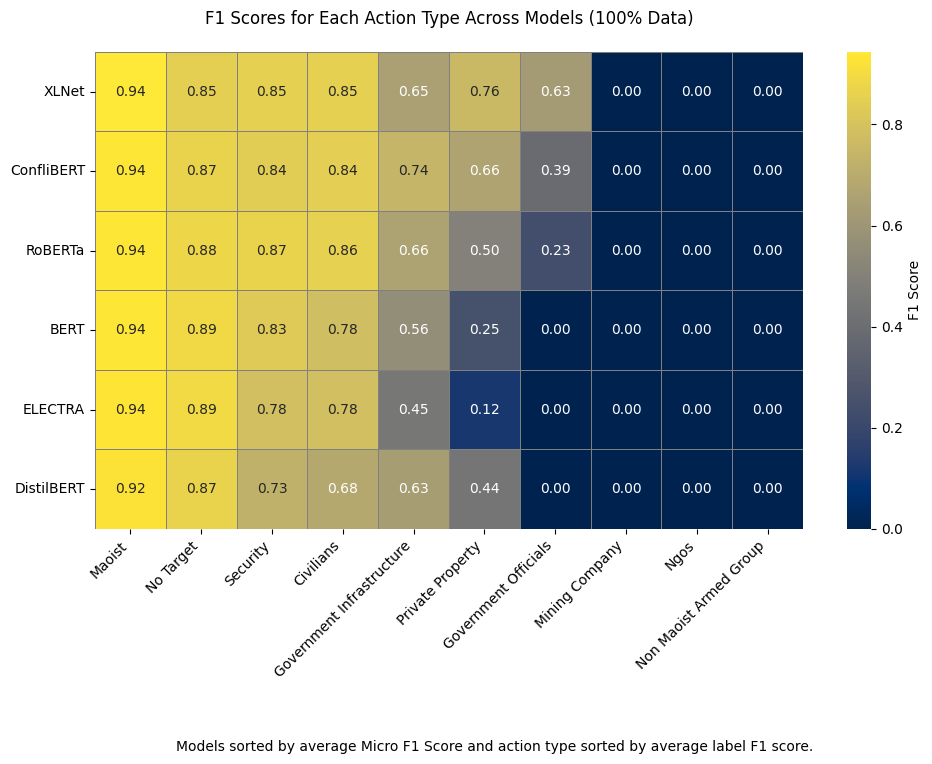

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset for models trained on 100% of the data
df_100 = df[df["fraction_label"] == "100%"]

# Extract F1-score columns related to specific labels (excluding averages)
label_f1_columns = [col for col in df_100.columns if col.startswith("eval_") and "_f1-score" in col and "avg" not in col]

# Select only the relevant columns along with the model label
df_f1_100 = df_100[["model_label"] + label_f1_columns]

# Rename "ConfliBERT-scr-cased" to "ConfliBERT" for clarity
#df_f1_100["model_label"] = df_f1_100["model_label"].replace({"ConfliBERT-scr-cased": "ConfliBERT"})

# Convert data to long format for heatmap visualization
df_f1_melted_100 = df_f1_100.melt(id_vars=["model_label"], var_name="Label", value_name="F1 Score")

# Clean label names (remove "eval_" prefix and "_f1-score" suffix for readability)
df_f1_melted_100["Label"] = df_f1_melted_100["Label"].str.replace("eval_", "").str.replace("_f1-score", "").str.replace("_", " ").str.title()

# Pivot the table so that models are on the y-axis and event types on the x-axis
df_f1_pivot_100 = df_f1_melted_100.pivot(index="model_label", columns="Label", values="F1 Score")

# Remove "Incident Summary" if it exists
df_f1_pivot_100 = df_f1_pivot_100.drop(columns="Incident Summary", errors="ignore")

# Sort event types (columns) by their average F1 score across models (descending order)
event_order = df_f1_pivot_100.mean().sort_values(ascending=False).index
df_f1_pivot_100 = df_f1_pivot_100[event_order]

# Sort models (rows) by their Micro F1 score (descending order) while ensuring all models are included
df_model_avg_f1 = df_100.set_index("model_label")["eval_micro avg_f1-score"].sort_values(ascending=False)
model_order = df_model_avg_f1.index
df_f1_pivot_100 = df_f1_pivot_100.loc[model_order]

# Plot the heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_f1_pivot_100, annot=True, fmt=".2f", cmap="cividis", linewidths=0.5, linecolor="gray", cbar_kws={'label': 'F1 Score'})

# Customize the plot
ax.set_title("F1 Scores for Each Target Type Across Models (100% Data)", pad=20)

# Add a custom note
plt.figtext(0.5, -0.08,
            "Models sorted by average Micro F1 Score and action type sorted by average label F1 score.",
            ha="center", fontsize=10)

# Remove X and Y axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Move event type labels (x-axis) to the bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# Adjust ticks
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.yticks(rotation=0)

# Show the heatmap
plt.tight_layout()
plt.show()


### Model performance vs. speed

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_speed_vs_accuracy(df, x_col, y_col, hue_col, size_col, title):
    """
    Creates a scatter (bubble) plot with customizable x and y axes.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis (e.g., throughput, latency)
    - y_col: Column name for the y-axis (e.g., accuracy, latency)
    - hue_col: Column name for the hue (color grouping, e.g., model name)
    - size_col: Column name for the size (bubble size, e.g., data fraction)
    - title: Custom plot title
    """

    # Initialize figure
    plt.figure(figsize=(7, 5))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,   # Color by model
        size=size_col,  # Bubble size by fraction
        sizes=(20, 400),  # Min to max size of markers
        alpha=0.7,  # Partial transparency
        palette="turbo"
    )

    # Clean up axis labels: Remove "eval_" prefix if present
    x_label_cleaned = x_col.replace("eval_", "").replace("_", " ").title()
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Labeling
    scatter.set_title(title)
    scatter.set_xlabel(x_label_cleaned)  # Use cleaned x-axis label
    scatter.set_ylabel(y_label_cleaned)  # Use cleaned y-axis label

    # Retrieve the current legend handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Convert column values to string for correct matching
    model_names = df[hue_col].astype(str).unique()
    fraction_values = sorted(df[size_col].astype(str).unique())

    # Filter legend items dynamically
    hue_handles = [h for h, l in zip(handles, labels) if l in model_names]
    hue_labels = [l for l in labels if l in model_names]

    size_handles = [h for h, l in zip(handles, labels) if l in fraction_values]
    size_labels = [l for l in labels if l in fraction_values]

    # Create the updated legends
    hue_legend = plt.legend(hue_handles, hue_labels, title="Model Name", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.gca().add_artist(hue_legend)  # Ensure the first legend stays

    size_legend = plt.legend(size_handles, size_labels, title="Fraction Raw", loc="lower left", bbox_to_anchor=(1.05, 0))

    # Show the plot
    plt.tight_layout()
    plt.show()


### Micro F1 vs. samples per second

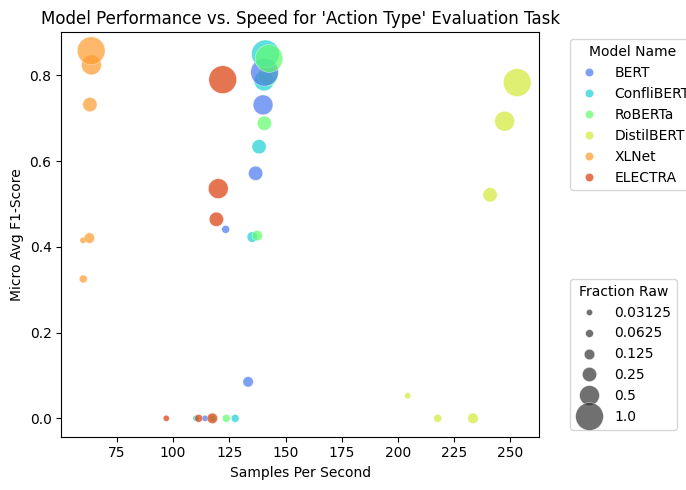

In [ ]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_samples_per_second",
    y_col="eval_micro avg_f1-score",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Target Type' Evaluation Task"
)